In [1]:
# ============================================================
# 1. IMPORTAR LIBRERÍAS
# ============================================================

import os
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Model

In [2]:
DRIVE_URL = '/content/drive/MyDrive/VISION-4/RETO4'
LOCAL_PATH = os.getcwd()

In [3]:
def detect_environment():
    try:
        ipython_env = str(get_ipython())

        if 'google.colab' in ipython_env:
            return "Google Colab"
        elif 'zmqshell' in ipython_env:
            return "Jupyter Notebook Local"
        else:
            return "Terminal interactiva de Python"
    except NameError:
        return "Script de Python estándar (.py)"


print(f"Entorno detectado: {detect_environment()}")

Entorno detectado: Jupyter Notebook Local


In [4]:
if detect_environment() != "Google Colab":
    BASE = LOCAL_PATH
else:
    BASE = DRIVE_URL
    from google.colab import drive

    drive.mount('/content/drive')

In [5]:
# ============================================================
# 2. MONTAR DRIVE Y DEFINIR PARÁMETROS
# ============================================================


DATASET_DIR = BASE + '/dataset'

NOISY_PATH = os.path.join(DATASET_DIR, "noisy")
GTRUTH_PATH = os.path.join(DATASET_DIR, "gtruth")

OUTPUT_PATH = BASE + '/evidence'
os.makedirs(OUTPUT_PATH, exist_ok=True)

TAMANO = 512
CHANNELS = 1

TEST_SIZE = 0.15
RANDOM_STATE = 123

BATCH_SIZE = 4
EPOCHS = 50
LEARNING_RATE = 1e-3

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Noisy path:", NOISY_PATH)
print("Ground truth path:", GTRUTH_PATH)
print("Output path:", OUTPUT_PATH)

Noisy path: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideFour\excercise_three/dataset\noisy
Ground truth path: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideFour\excercise_three/dataset\gtruth
Output path: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideFour\excercise_three/evidence


In [6]:
# ============================================================
# 3. VERIFICAR CARPETAS
# ============================================================

print("Existe noisy:", os.path.exists(NOISY_PATH))
print("Existe gtruth:", os.path.exists(GTRUTH_PATH))

if not os.path.exists(NOISY_PATH):
    raise FileNotFoundError(f"No existe la carpeta: {NOISY_PATH}")

if not os.path.exists(GTRUTH_PATH):
    raise FileNotFoundError(f"No existe la carpeta: {GTRUTH_PATH}")

Existe noisy: True
Existe gtruth: True


In [7]:
# ============================================================
# 4. LISTAR ARCHIVOS .TIFF
# ============================================================

def listar_tiff(folder):
    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".tiff", ".tif"))
    ]
    return sorted(files)


noisy_files = listar_tiff(NOISY_PATH)
gtruth_files = listar_tiff(GTRUTH_PATH)

print("Total noisy .tiff:", len(noisy_files))
print("Total gtruth .tiff:", len(gtruth_files))

print("Primeros noisy:", noisy_files[:5])
print("Primeros gtruth:", gtruth_files[:5])

Total noisy .tiff: 16
Total gtruth .tiff: 16
Primeros noisy: ['0_0.tiff', '0_1024.tiff', '0_1536.tiff', '0_512.tiff', '1024_0.tiff']
Primeros gtruth: ['0_0.tiff', '0_1024.tiff', '0_1536.tiff', '0_512.tiff', '1024_0.tiff']


In [8]:
# ============================================================
# 5. EMPAREJAR ARCHIVOS NOISY Y GTRUTH
# ============================================================

noisy_set = set(noisy_files)
gtruth_set = set(gtruth_files)

common_files = sorted(list(noisy_set.intersection(gtruth_set)))

print("Pares encontrados:", len(common_files))

if len(common_files) == 0:
    raise ValueError(
        "No se encontraron archivos .tiff con el mismo nombre en noisy y gtruth. "
        "Verifica que los nombres coincidan exactamente."
    )

missing_in_gtruth = sorted(list(noisy_set - gtruth_set))
missing_in_noisy = sorted(list(gtruth_set - noisy_set))

print("Archivos noisy sin gtruth:", len(missing_in_gtruth))
print("Archivos gtruth sin noisy:", len(missing_in_noisy))

Pares encontrados: 16
Archivos noisy sin gtruth: 0
Archivos gtruth sin noisy: 0


In [9]:
# ============================================================
# 6. CARGAR Y PREPROCESAR IMÁGENES
# ============================================================

def leer_imagen_gris(path, size=TAMANO):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"No se pudo leer la imagen: {path}")

    img = cv2.resize(img, (size, size))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=-1)

    return img


noisy_images = []
gtruth_images = []
valid_files = []

for filename in common_files:
    noisy_path = os.path.join(NOISY_PATH, filename)
    gtruth_path = os.path.join(GTRUTH_PATH, filename)

    try:
        noisy_img = leer_imagen_gris(noisy_path)
        gtruth_img = leer_imagen_gris(gtruth_path)

        noisy_images.append(noisy_img)
        gtruth_images.append(gtruth_img)
        valid_files.append(filename)

    except Exception as e:
        print("Archivo omitido:", filename, "Error:", e)

noisy_images = np.array(noisy_images, dtype="float32")
gtruth_images = np.array(gtruth_images, dtype="float32")

print("Noisy shape:", noisy_images.shape)
print("Ground truth shape:", gtruth_images.shape)
print("Pares válidos:", len(valid_files))

Noisy shape: (16, 512, 512, 1)
Ground truth shape: (16, 512, 512, 1)
Pares válidos: 16


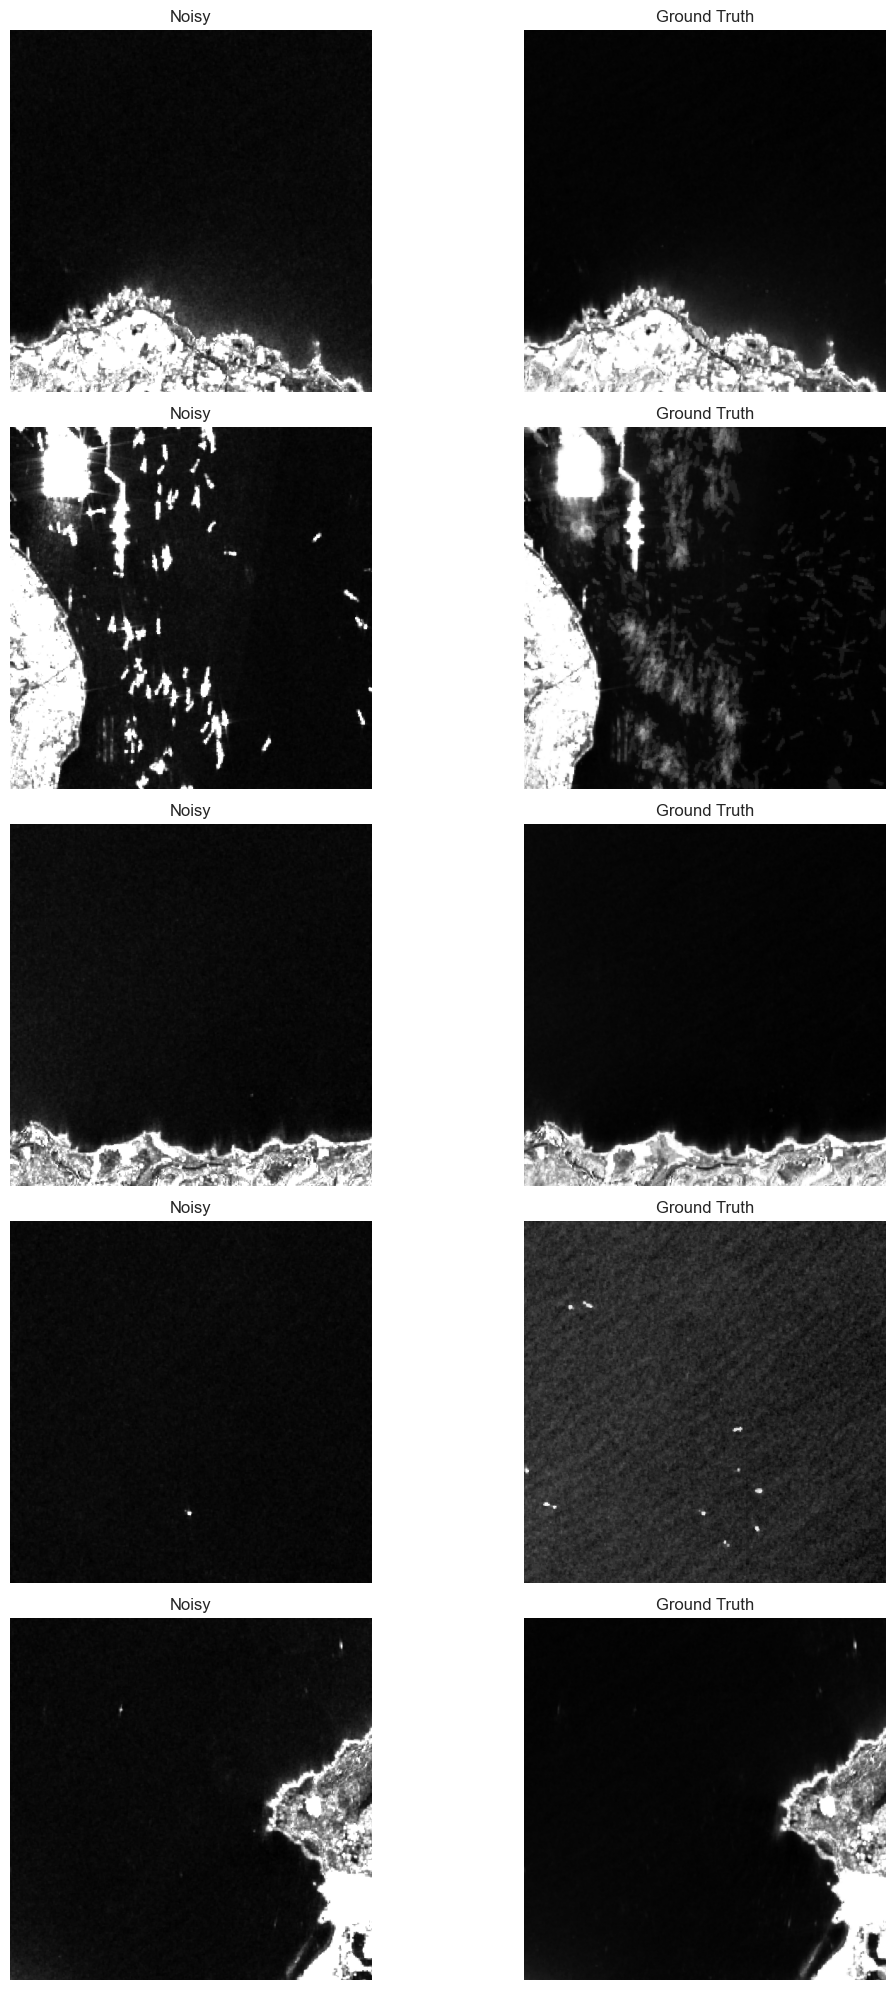

In [10]:
# ============================================================
# 7. VISUALIZAR PARES NOISY / GTRUTH
# ============================================================

def mostrar_pares(noisy_array, gtruth_array, n=5):
    indices = np.random.choice(len(noisy_array), size=min(n, len(noisy_array)), replace=False)

    plt.figure(figsize=(12, 4 * len(indices)))

    for row, idx in enumerate(indices):
        plt.subplot(len(indices), 2, row * 2 + 1)
        plt.imshow(noisy_array[idx].squeeze(), cmap="gray")
        plt.title("Noisy")
        plt.axis("off")

        plt.subplot(len(indices), 2, row * 2 + 2)
        plt.imshow(gtruth_array[idx].squeeze(), cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


mostrar_pares(noisy_images, gtruth_images, n=5)

In [11]:
# ============================================================
# 8. DIVIDIR TRAIN / TEST
# ============================================================

indices = np.arange(len(noisy_images))

train_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

noisy_train_data = noisy_images[train_idx]
noisy_test_data = noisy_images[test_idx]

train_data = gtruth_images[train_idx]
test_data = gtruth_images[test_idx]

test_files = [valid_files[i] for i in test_idx]

print("Noisy train:", noisy_train_data.shape)
print("Noisy test:", noisy_test_data.shape)
print("GTruth train:", train_data.shape)
print("GTruth test:", test_data.shape)

Noisy train: (13, 512, 512, 1)
Noisy test: (3, 512, 512, 1)
GTruth train: (13, 512, 512, 1)
GTruth test: (3, 512, 512, 1)


In [12]:
# ============================================================
# 9. DEFINIR AUTOENCODER
# ============================================================

tf.keras.backend.clear_session()

input_img = layers.Input(shape=(TAMANO, TAMANO, CHANNELS), name="input_noisy")

# Encoder
x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(input_img)
x = layers.MaxPooling2D((2, 2), padding="same")(x)

x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)

# Bottleneck
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same", name="bottleneck")(x)

# Decoder
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)

output_img = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same", name="output_filtered")(x)

autoencoder = Model(input_img, output_img, name="SAR_Despeckling_Autoencoder")

autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=["mae"]
)

autoencoder.summary()

Model: "SAR_Despeckling_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_noisy (InputLayer)        │ (None, 512, 512, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 512, 512, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Conv2D)             │ (None, 128, 128, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 256, 256, 32)   │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 512, 512, 32)   │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_filtered (Conv2D)        │ (None, 512, 512, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,817 (292.25 KB)

 Trainable params: 74,817 (292.25 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# ============================================================
# 10. CALLBACKS
# ============================================================

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6
    )
]

In [ ]:
# ============================================================
# 11. ENTRENAR AUTOENCODER
# ============================================================

history = autoencoder.fit(
    x=noisy_train_data,
    y=train_data,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(noisy_test_data, test_data),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - loss: 0.6909 - mae: 0.3890 - val_loss: 0.6861 - val_mae: 0.3862 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - loss: 0.6818 - mae: 0.3832 - val_loss: 0.6755 - val_mae: 0.3799 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - loss: 0.6631 - mae: 0.3701 - val_loss: 0.6618 - val_mae: 0.3709 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - loss: 0.6346 - mae: 0.3486 - val_loss: 0.6601 - val_mae: 0.3652 - learning_rate: 0.0010
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - loss: 0.6184 - mae: 0.3348 - val_loss: 0.6320 - val_mae: 0.3503 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 0.5999 - mae: 0.3248 - val_loss: 0.6101 - val_mae: 0.3354 - learning_rate: 0.0010
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - loss: 0.5768 - mae: 0.3087 - val_loss: 0.5787 - val_mae: 0.3120 - learning_rate: 0.0010
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1

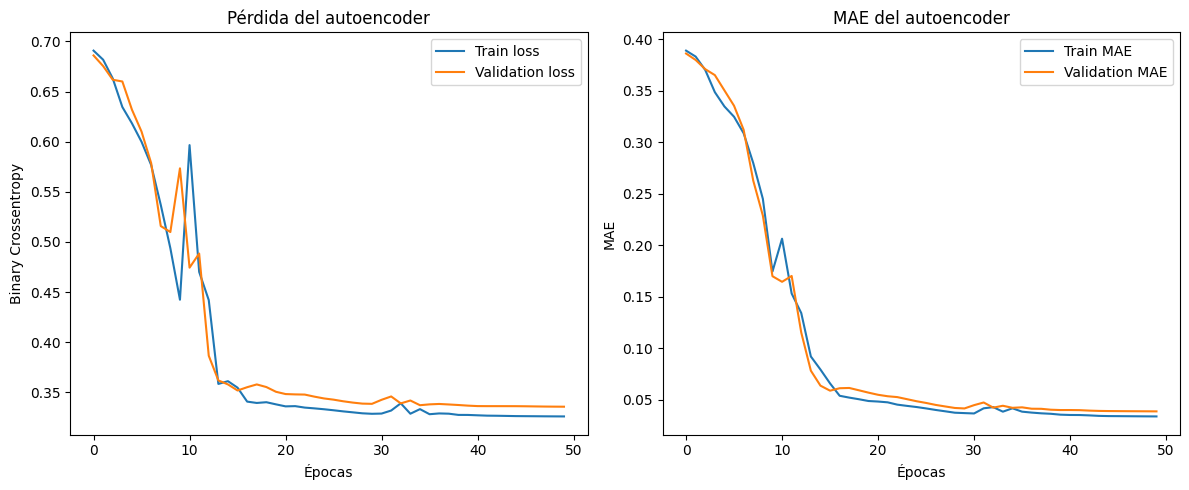

In [15]:
# ============================================================
# 12. GRAFICAR ENTRENAMIENTO
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Pérdida del autoencoder")
plt.xlabel("Épocas")
plt.ylabel("Binary Crossentropy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")
plt.title("MAE del autoencoder")
plt.xlabel("Épocas")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# 13. GENERAR PREDICCIONES
# ============================================================

predictions = autoencoder.predict(noisy_test_data, batch_size=BATCH_SIZE)

print("Predictions shape:", predictions.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
Predictions shape: (3, 512, 512, 1)


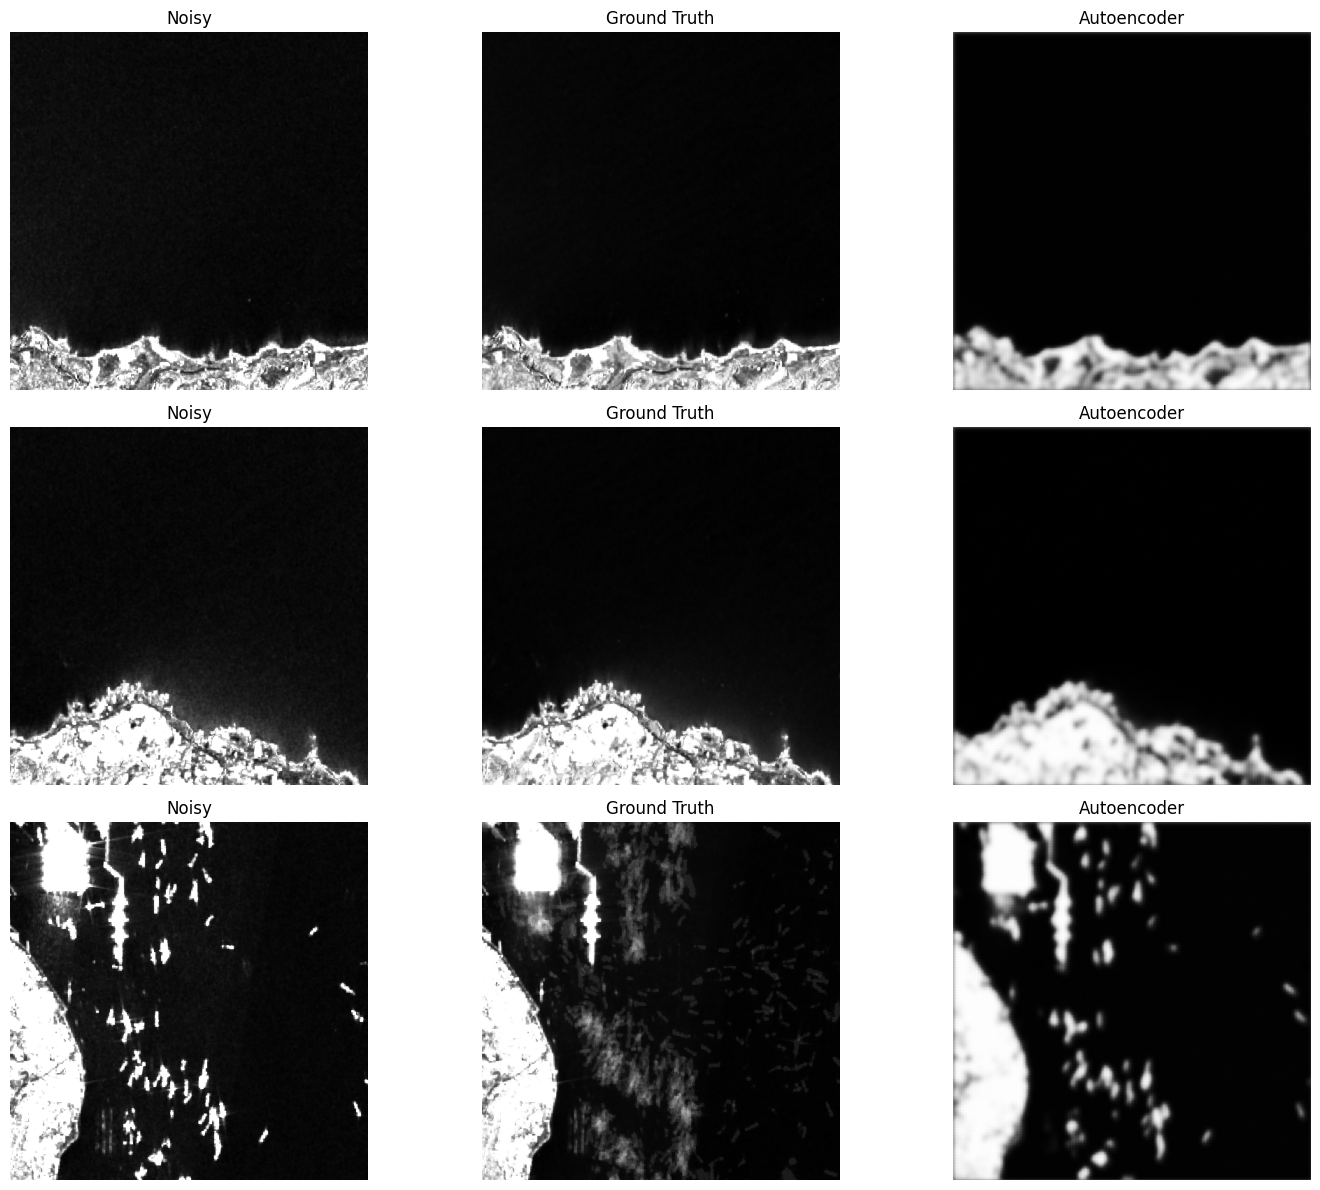

In [17]:
# ============================================================
# 14. VISUALIZAR RESULTADOS
# ============================================================

def mostrar_resultados(noisy_array, gtruth_array, pred_array, n=5):
    indices = np.random.choice(len(noisy_array), size=min(n, len(noisy_array)), replace=False)

    plt.figure(figsize=(15, 4 * len(indices)))

    for row, idx in enumerate(indices):
        plt.subplot(len(indices), 3, row * 3 + 1)
        plt.imshow(noisy_array[idx].squeeze(), cmap="gray")
        plt.title("Noisy")
        plt.axis("off")

        plt.subplot(len(indices), 3, row * 3 + 2)
        plt.imshow(gtruth_array[idx].squeeze(), cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(len(indices), 3, row * 3 + 3)
        plt.imshow(pred_array[idx].squeeze(), cmap="gray")
        plt.title("Autoencoder")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


mostrar_resultados(noisy_test_data, test_data, predictions, n=5)

In [18]:
# ============================================================
# 15. FUNCIONES DE MÉTRICAS
# ============================================================

def calcular_psnr(y_true, y_pred):
    return tf.image.psnr(y_true, y_pred, max_val=1.0).numpy()


def calcular_ssim(y_true, y_pred):
    return tf.image.ssim(y_true, y_pred, max_val=1.0).numpy()


def calcular_enl(img):
    """
    ENL = media^2 / varianza
    Se calcula sobre toda la imagen como aproximación.
    En SAR idealmente se calcula sobre una región homogénea.
    """
    img = img.squeeze().astype("float32")
    mean = np.mean(img)
    var = np.var(img)

    if var == 0:
        return np.nan

    return (mean ** 2) / var

In [19]:
# ============================================================
# 16. CALCULAR MÉTRICAS POR IMAGEN
# ============================================================

rows = []

for i in range(len(noisy_test_data)):
    noisy_img = noisy_test_data[i:i + 1]
    gt_img = test_data[i:i + 1]
    pred_img = predictions[i:i + 1]

    psnr_noisy = calcular_psnr(gt_img, noisy_img)[0]
    psnr_pred = calcular_psnr(gt_img, pred_img)[0]

    ssim_noisy = calcular_ssim(gt_img, noisy_img)[0]
    ssim_pred = calcular_ssim(gt_img, pred_img)[0]

    enl_noisy = calcular_enl(noisy_img)
    enl_pred = calcular_enl(pred_img)
    enl_gt = calcular_enl(gt_img)

    rows.append({
        "archivo": test_files[i],
        "PSNR_noisy": psnr_noisy,
        "PSNR_autoencoder": psnr_pred,
        "SSIM_noisy": ssim_noisy,
        "SSIM_autoencoder": ssim_pred,
        "ENL_noisy": enl_noisy,
        "ENL_autoencoder": enl_pred,
        "ENL_gtruth": enl_gt
    })

df_metrics = pd.DataFrame(rows)

df_metrics.head()

,archivo,PSNR_noisy,PSNR_autoencoder,SSIM_noisy,SSIM_autoencoder,ENL_noisy,ENL_autoencoder,ENL_gtruth
0,1024_512.tiff,30.167498,23.494932,0.925129,0.869015,0.566491,0.567846,0.536444
1,1536_1536.tiff,17.576715,19.726965,0.730916,0.706572,0.659446,0.635466,0.671191
2,1024_0.tiff,29.662758,24.774326,0.921361,0.897752,0.584555,0.579367,0.552263


In [20]:
# ============================================================
# 17. RESUMEN DE MÉTRICAS
# ============================================================

summary_metrics = df_metrics.drop(columns=["archivo"]).mean().to_frame(name="promedio")
summary_metrics

,promedio
PSNR_noisy,25.802322
PSNR_autoencoder,22.665407
SSIM_noisy,0.859135
SSIM_autoencoder,0.824446
ENL_noisy,0.603498
ENL_autoencoder,0.594226
ENL_gtruth,0.586633


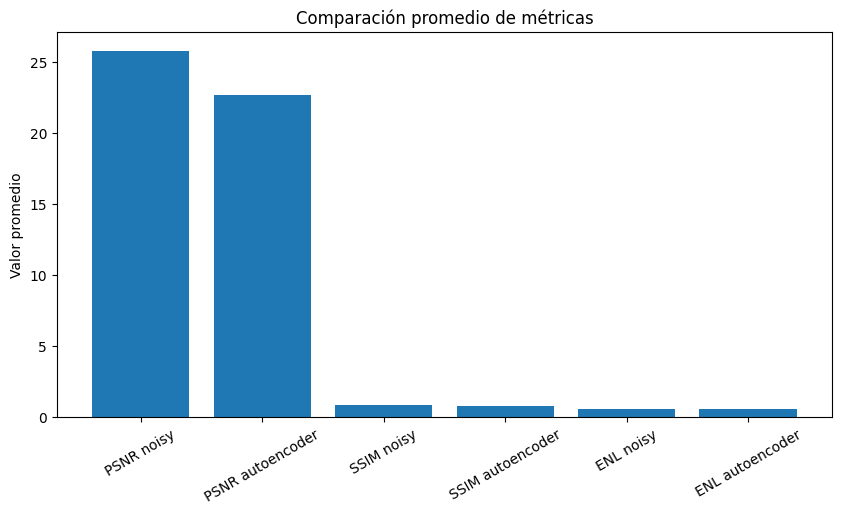

In [21]:
# ============================================================
# 18. COMPARACIÓN VISUAL DE MÉTRICAS
# ============================================================

metric_compare = {
    "PSNR noisy": df_metrics["PSNR_noisy"].mean(),
    "PSNR autoencoder": df_metrics["PSNR_autoencoder"].mean(),
    "SSIM noisy": df_metrics["SSIM_noisy"].mean(),
    "SSIM autoencoder": df_metrics["SSIM_autoencoder"].mean(),
    "ENL noisy": df_metrics["ENL_noisy"].mean(),
    "ENL autoencoder": df_metrics["ENL_autoencoder"].mean()
}

plt.figure(figsize=(10, 5))
plt.bar(metric_compare.keys(), metric_compare.values())
plt.title("Comparación promedio de métricas")
plt.xticks(rotation=30)
plt.ylabel("Valor promedio")
plt.show()

In [22]:
# ============================================================
# 19. GUARDAR MODELO Y EVIDENCIAS
# ============================================================

model_path = os.path.join(OUTPUT_PATH, "autoencoder_sar_despeckling.keras")
autoencoder.save(model_path)

metrics_path = os.path.join(OUTPUT_PATH, "metricas_autoencoder.csv")
df_metrics.to_csv(metrics_path, index=False)

summary_path = os.path.join(OUTPUT_PATH, "resumen_metricas_autoencoder.csv")
summary_metrics.to_csv(summary_path)

print("Modelo guardado en:", model_path)
print("Métricas guardadas en:", metrics_path)
print("Resumen guardado en:", summary_path)

Modelo guardado en: /content/drive/MyDrive/VISION-4/RETO3/evidencias_autoencoder/autoencoder_sar_despeckling.keras
Métricas guardadas en: /content/drive/MyDrive/VISION-4/RETO3/evidencias_autoencoder/metricas_autoencoder.csv
Resumen guardado en: /content/drive/MyDrive/VISION-4/RETO3/evidencias_autoencoder/resumen_metricas_autoencoder.csv


In [23]:
# ============================================================
# 20. GUARDAR IMÁGENES FILTRADAS
# ============================================================

filtered_dir = os.path.join(OUTPUT_PATH, "filtered_tiff")
os.makedirs(filtered_dir, exist_ok=True)

for i, filename in enumerate(test_files):
    pred_img = predictions[i].squeeze()
    pred_uint8 = np.clip(pred_img * 255, 0, 255).astype("uint8")

    output_filename = filename.replace(".tiff", "_filtered.tiff").replace(".tif", "_filtered.tif")
    output_file_path = os.path.join(filtered_dir, output_filename)

    cv2.imwrite(output_file_path, pred_uint8)

print("Imágenes filtradas guardadas en:", filtered_dir)

Imágenes filtradas guardadas en: /content/drive/MyDrive/VISION-4/RETO3/evidencias_autoencoder/filtered_tiff
